# 1. Install necessary Libraries
In this part, we'll begin by installing necessary libraries needed for running our computer vision training and testing scripts\
**Note:** Only run once unless new package is needed as it'll be installed inside the VM OS boot disk and will not be removed even after server restart

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
%pip install transformers scikit-learn pillow pandas numpy matplotlib huggingface_hub ipywidgets opencv-python google-cloud-storage

Looking in indexes: https://download.pytorch.org/whl/cu128

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 2. Download Dataset From Storage Bucket to Jupyter Server
This is to reduce continuous Read/Write Call from Storage Bucket and reduce cost. It will create a directory, and only download the dataset image inside the directory if the dataset image is not yet downloaded.

In [2]:
from google.cloud import storage
import os

client = storage.Client()
bucket = client.bucket('naic-dataset-images')

# 1. Create the local directory
os.makedirs('dataset/image', exist_ok=True)

# 2. Download labels.csv permanently to the local disk
print("Fetching labels.csv...")
blob_csv = bucket.blob('labels.csv')
# Save it locally instead of holding it in memory
blob_csv.download_to_filename('dataset/labels.csv')
print("labels.csv saved to dataset/labels.csv")

# 3. Download the images
blobs = bucket.list_blobs(prefix='image/')
print("\nStarting image download...")

download_count = 0
for i, blob in enumerate(blobs):
    if not blob.name.endswith('/'):
        filename = blob.name.split('/')[-1]
        local_path = f'dataset/image/{filename}'

        # Only download if the file isn't already on the disk
        if not os.path.exists(local_path):
            blob.download_to_filename(local_path)
            download_count += 1

    if i % 500 == 0:
        print(f"Scanned {i} files...")

print(f"Download complete! Fetched {download_count} new images. L4 GPU is ready to work.")

Fetching labels.csv...
labels.csv saved to dataset/labels.csv

Starting image download...
Scanned 0 files...
Scanned 500 files...
Scanned 1000 files...
Scanned 1500 files...
Scanned 2000 files...
Scanned 2500 files...
Scanned 3000 files...
Scanned 3500 files...
Scanned 4000 files...
Scanned 4500 files...
Download complete! Fetched 0 new images. L4 GPU is ready to work.


# 3. Read CSV File from Storage Bucket
In this part, since we need to create a variable df using pandas to load the csv file, we should separate this part from downloading part as variable is voilatile and will be reset every time kernel/server restarts

In [3]:
import pandas as pd

# Read the CSV directly from the VM's high-speed local disk
df = pd.read_csv('dataset/labels.csv')

print(f"Ready to train with {len(df)} images on local disk.")

Ready to train with 4939 images on local disk.


# 4. CLAHE Data Preprocessing + Retina Cropping
In this part, we'll write Contrast Limited Adaptive Histogram Equalization (CLAHE) preprocessing function logic, which is used to enhance the blurry dataset images to enable clearer image and allow small pixels to be detected. Besides that, we also implemented retina cropping to determine the eye fundus pixels more accurately

In [4]:
import cv2
import numpy as np
from PIL import Image

def crop_fundus(image, tol=10):
    """
    Removes the useless black borders around the circular fundus image.
    tol: Tolerance for black pixels (values below 10 are considered background).
    """
    if isinstance(image, Image.Image):
        image = np.array(image)

    # Convert to grayscale to easily separate the eye from the background
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Create a mask of all pixels brighter than the tolerance
    mask = gray > tol

    # Get the coordinates of the actual eyeball
    coords = np.argwhere(mask)

    # Safety check: if the image is completely black, return the original
    if coords.size == 0:
        return image

    # Find the bounding box (min and max Y, min and max X)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1 # +1 to include the last pixel

    # Crop the image using numpy slicing
    cropped = image[y0:y1, x0:x1]

    return cropped

def preprocess_fundus(image):
    """
    The ultimate medical preprocessing pipeline.
    1. Tight crop the retina.
    2. Apply Green Channel CLAHE.
    """
    # Step 1: Remove black borders
    cropped_img = crop_fundus(image)

    # Step 2: Split into R, G, B channels
    r, g, b = cv2.split(cropped_img)

    # Step 3: Apply Green Channel CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g_enhanced = clahe.apply(g)

    # Step 4: Merge and return as PIL Image for PyTorch
    enhanced = cv2.merge((r, g_enhanced, b))
    return Image.fromarray(enhanced)

# 5. Preprocessed vs Processed Image Visualization Comparison
In this part, we'll run a script to compare the dataset images before and after preprocessing to see if it's successful and fulfills our requirements

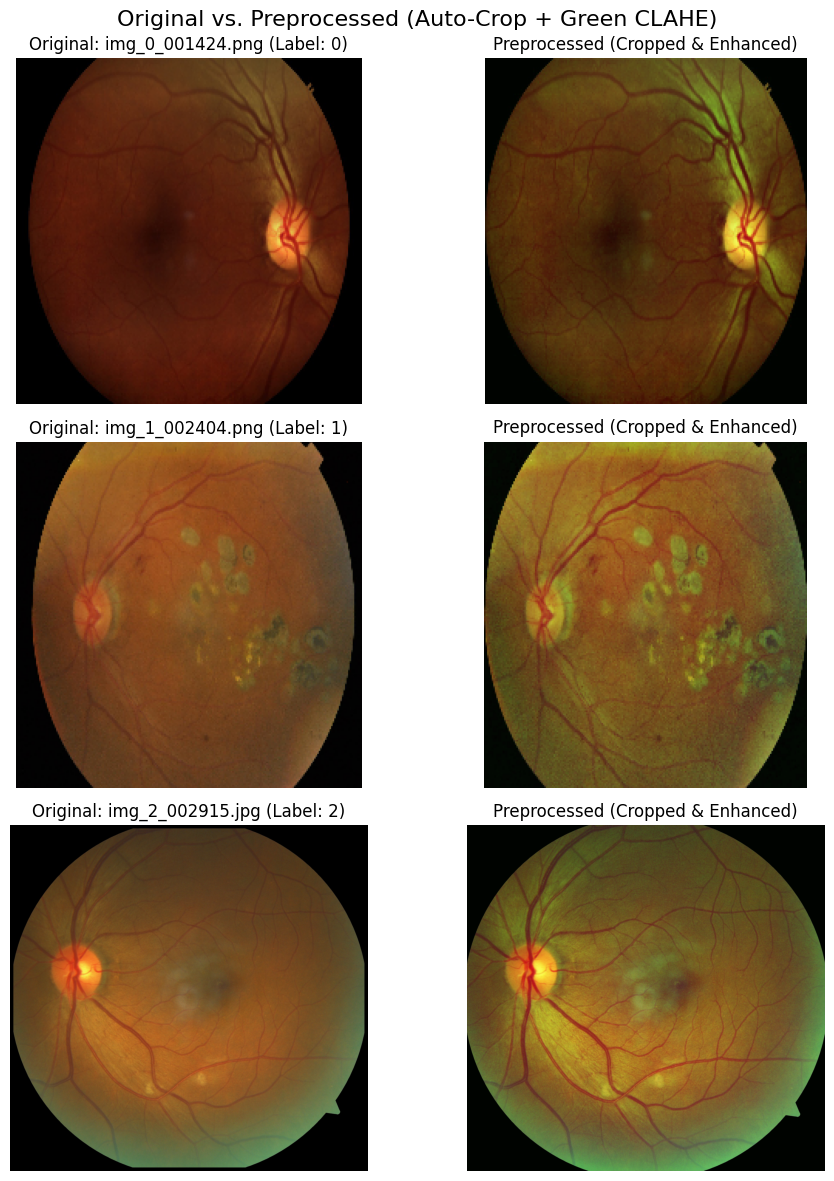

In [5]:
import matplotlib.pyplot as plt

def display_preprocessing_samples(dataframe, img_directory, num_samples=3):
    """
    Randomly samples images from the dataframe and displays a side-by-side
    comparison of the original vs. preprocessed images.
    """
    # Take random samples from the dataframe
    samples = dataframe.sample(n=num_samples)

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    fig.suptitle("Original vs. Preprocessed (Auto-Crop + Green CLAHE)", fontsize=16)

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(img_directory, row['Image'])
        original_img = Image.open(img_path).convert("RGB")

        # Apply the medical preprocessing pipeline
        preprocessed_img = preprocess_fundus(original_img)

        # Plot Original
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f"Original: {row['Image']} (Label: {row['Label']})")
        axes[i, 0].axis('off')

        # Plot Preprocessed
        axes[i, 1].imshow(preprocessed_img)
        axes[i, 1].set_title(f"Preprocessed (Cropped & Enhanced)")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualizer (Ensure 'df' and 'dataset/image' are defined in your environment)
display_preprocessing_samples(df, "dataset/image/", num_samples=3)

# 6. Custom Dataset Loader
Since we're using a custom dataset, we will need to write a custom dataset loader to pass our image data to the model


In [6]:
from torch.utils.data import Dataset
from PIL import Image
import os

class MedicalDatasetLoader(Dataset):
    def __init__(self, df, img_dir, transform=None, use_preprocessing=True):
        self.data = df # Differentiate between train_df, val_df and test_df
        self.img_dir = img_dir # Image Directory Path
        self.transform = transform # Data augmentation
        self.use_preprocessing = use_preprocessing # Apply cropping & CLAHE

    def __len__(self):
        return len(self.data) # Calculate the number of rows of the dataset

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]['Image'] # Get the image name from the csv header
        label = int(self.data.iloc[idx]['Label']) # Get the Label value from csv header

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        # Call the combined auto-crop and green CLAHE pipeline
        if self.use_preprocessing:
            image = preprocess_fundus(image)

        if self.transform: # Implement Data Augmentation (Resize, Flip, etc.)
            image = self.transform(image)

        return image, label

# 7. Setup Cuda Device
Here in this part, we check if PyTorch detects our GPU cuda cores

In [ ]:
import torch

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Check if cuda is detected by pytorch, fallback to CPU otherwise
print("Cuda available: ", torch.cuda.is_available())

Cuda available:  False


# 8. Setup Model
In this part, we will load the Deep Learning model from huggingface. Remember to change the library imports and pretrain name based on your designated model choice.\
Feel free to design the inner architecture of your model choice such as its layers, activation function types and Feed Forward Network (FFN) layers here as well

In [8]:
from transformers import AutoImageProcessor, ConvNextForImageClassification

# 1. Define the model variant
model_name = 'facebook/convnext-small-224'

# 2. Load ConvNext with the built-in classification head
# We set num_labels=5 for your retinopathy severity classes
model = ConvNextForImageClassification.from_pretrained(
    model_name,
    num_labels=5,
    ignore_mismatched_sizes=True # Essential when replacing the ImageNet head with 5 classes
).to(device)

# 3. Load the processor for normalization values
processor = AutoImageProcessor.from_pretrained(model_name)

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/344 [00:00<?, ?it/s]

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-small-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


# 9. Data Preprocessing
In this part, we will perform data augmentation on our dataset through torchvision library, then split our dataset into training and validation data.

In [9]:
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import pandas as pd

# Data augmentation — RandomErasing proven effective from prior SwinV2 experiments
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15))
])

val_transform = transforms.Compose([ # No data augmentation for val/testing
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Step 1: Train+Val / Test (80/20 stratified split)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Label'],
    random_state=42
)

test_dataset = MedicalDatasetLoader(test_df, "dataset/image", val_transform, use_preprocessing=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
print(f"Test: {len(test_df)}")

Test: 988


# 10. Experiment Logging Class
In this part, we'll create a log class that can help us to logs our hyperparameter lists as well as result metrics.

In [10]:
import json
from datetime import datetime
import os

class ExperimentTracker:
    def __init__(self, base_dir="experiments", resume_dir=None):
        self.base_dir = base_dir
        os.makedirs(base_dir, exist_ok=True)

        if resume_dir:
            self.exp_dir = resume_dir
            metrics_path = os.path.join(self.exp_dir, "metrics.json")
            if os.path.exists(metrics_path):
                with open(metrics_path) as f:
                    data = json.load(f)
                    self.epoch_metrics = data.get("epoch_metrics", [])
                    self.final_metrics = data.get("final_metrics", {})
                    self.config = data.get("config", {})
            else:
                self.epoch_metrics = []
                self.final_metrics = {}
                self.config = {}
            print(f"Resuming experiment from: {self.exp_dir}")
        else:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            self.exp_dir = os.path.join(base_dir, f"exp_{timestamp}")
            os.makedirs(self.exp_dir)
            self.epoch_metrics = []
            self.final_metrics = {}
            self.config = {}

    # ---------------- CONFIG ----------------
    def log_config(self, config):
        self.config = config
        with open(os.path.join(self.exp_dir, "config.json"), "w") as f:
            json.dump(config, f, indent=4)

    # Saves full state for recovery (called every epoch)
    def save_checkpoint(self, fold, epoch, model, optimizer, scheduler, scaler, is_best=False):
        checkpoint = {
            'fold': fold,
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
        }
        ckpt_path = os.path.join(self.exp_dir, f"checkpoint_fold_{fold}.pth")
        torch.save(checkpoint, ckpt_path)

        if is_best:
            torch.save(model.state_dict(), os.path.join(self.exp_dir, f"best_model_fold_{fold}.pth"))

    # Loads state if the script restarts mid-fold
    def load_checkpoint(self, fold, model, optimizer, scheduler, scaler):
        ckpt_path = os.path.join(self.exp_dir, f"checkpoint_fold_{fold}.pth")
        if os.path.exists(ckpt_path):
            print(f"Resuming fold {fold} from checkpoint: {ckpt_path}")
            ckpt = torch.load(ckpt_path, map_location=device)
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            scaler.load_state_dict(ckpt['scaler_state_dict'])
            return ckpt['epoch'] + 1
        return 0

    # ---------------- PER EPOCH ----------------
    def log_epoch(self, epoch, train_loss, val_loss, train_acc, val_acc, current_lr):
        self.epoch_metrics.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "learning_rate": current_lr
        })

    # ---------------- FINAL METRICS ----------------
    def log_final_metrics(self, split, acc, prec, rec, f1, roc_auc, cm):
        if not isinstance(self.final_metrics, dict):
            self.final_metrics = {}
        self.final_metrics[split] = {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "roc_auc_score": roc_auc,
            "confusion_matrix": cm.tolist()
        }

    # ---------------- SAVE ----------------
    def save_all(self):
        with open(os.path.join(self.exp_dir, "metrics.json"), "w") as f:
            json.dump({
                "config": self.config,
                "epoch_metrics": self.epoch_metrics,
                "final_metrics": self.final_metrics
            }, f, indent=4)

    def save_model(self, model, name="best_model.pth"):
        torch.save(model.state_dict(), os.path.join(self.exp_dir, name))

# 11. CBAM Attention Module
Channel Attention Module (CAM) + Spatial Attention Module (SAM) = CBAM.
Inserted before the final classifier head to help the model focus on lesion regions.
This improves classification AND produces cleaner Grad-CAM heatmaps for demo (worth 10% judging marks).

In [ ]:
import torch
import torch.nn as nn


class ECA(nn.Module):
    """Efficient Channel Attention with adaptive kernel size."""
    def __init__(self, in_channels, gamma=2, b=1):
        super().__init__()
        # Adaptive kernel size: k = |log2(C) / gamma| + b/gamma
        t = int(abs((np.log2(in_channels)) / gamma) + b / gamma)
        k = t if t % 2 else t + 1  # Ensure odd kernel size
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=(k-1)//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (B, C, H, W)
        b, c, h, w = x.size()
        y = self.avg_pool(x)  # (B, C, 1, 1)
        y = y.squeeze(-1).transpose(1, 2)  # (B, 1, C)
        y = self.conv(y)  # (B, 1, C)
        y = self.sigmoid(y)  # (B, 1, C)
        y = y.transpose(1, 2).unsqueeze(-1)  # (B, C, 1, 1)
        return x * y  # Broadcast multiply

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        return self.sigmoid(avg_out + max_out).view(b, c, 1, 1) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(combined)) * x

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attn = ChannelAttention(in_channels, reduction)
        self.spatial_attn = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attn(x)
        x = self.spatial_attn(x)
        return x

class ConvNextWithCBAM(nn.Module):
    """Wraps the HuggingFace ConvNeXt model and inserts CBAM before the classifier."""
    def __init__(self, base_model, feature_dim):
        super().__init__()
        self.convnext = base_model.convnext
        self.cbam = CBAM(feature_dim)
        self.classifier = base_model.classifier

    def forward(self, pixel_values):
        features = self.convnext(pixel_values).last_hidden_state  # (B, C, H, W)
        attended = self.cbam(features)
        # Global average pool -> flatten -> classify
        pooled = attended.mean(dim=[-2, -1])  # (B, C)
        logits = self.classifier(pooled)
        return logits

# 12. Focal Loss + Ordinal Penalty Loss
- **Focal Loss** (gamma=2.0): Penalizes easy-to-classify samples less, focuses on hard minority classes like Class 3
- **Ordinal Penalty Loss**: Penalizes misclassifications proportionally to their distance from the true class (e.g., predicting Class 0 when true is Class 4 is worse than predicting Class 3)
- **Combined**: L = 0.7 x Focal + 0.3 x Ordinal — ConvNeXt's global features handle easy classes well, ordinal pushes harder on boundary cases

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

class OrdinalPenaltyLoss(nn.Module):
    """Penalizes predictions based on distance from true class.
    For DR severity 0-4, predicting 0 when true is 4 gets a higher penalty than predicting 3."""
    def __init__(self, num_classes=5, reduction='mean'):
        super().__init__()
        self.num_classes = num_classes
        self.reduction = reduction

    def forward(self, inputs, targets):
        probs = F.softmax(inputs, dim=1)
        # Create distance matrix: |i - j| for each class pair, normalized by (num_classes - 1)
        class_indices = torch.arange(self.num_classes, device=inputs.device).float()
        # (B, num_classes) distance from each sample's true label to each class
        distances = torch.abs(class_indices.unsqueeze(0) - targets.unsqueeze(1).float()) / (self.num_classes - 1)
        # Weighted cross-entropy: weight each class probability by its ordinal distance
        ordinal_loss = (probs * distances).sum(dim=1)

        if self.reduction == 'mean':
            return ordinal_loss.mean()
        elif self.reduction == 'sum':
            return ordinal_loss.sum()
        return ordinal_loss

class CombinedLoss(nn.Module):
    """Combined Focal + Ordinal loss with configurable weighting."""
    def __init__(self, focal_gamma=2.0, focal_weight=0.7, ordinal_weight=0.3, num_classes=5):
        super().__init__()
        self.focal = FocalLoss(gamma=focal_gamma)
        self.ordinal = OrdinalPenaltyLoss(num_classes=num_classes)
        self.focal_weight = focal_weight
        self.ordinal_weight = ordinal_weight

    def forward(self, inputs, targets):
        return self.focal_weight * self.focal(inputs, targets) + self.ordinal_weight * self.ordinal(inputs, targets)



# 13. Severity-Aware MixUp
Only mixes samples from adjacent severity classes (e.g., Class 2 with Class 1 or 3).
This creates realistic synthetic training data — a retina with severity 2 blended with severity 3 is clinically plausible.
Mixing Class 0 (healthy) with Class 4 (severe) would create unrealistic images.

In [ ]:
import torch
import numpy as np

def severity_aware_mixup(images, labels, alpha=0.4):
    """MixUp that only blends samples from adjacent severity classes (+/- 1).
    Returns mixed images and soft label vectors for cross-entropy.

    Args:
        images: (B, C, H, W) tensor
        labels: (B,) tensor of integer class labels 0-4
        alpha: Beta distribution parameter for mixing ratio
    Returns:
        mixed_images: (B, C, H, W) blended images
        labels_a: (B,) original labels
        labels_b: (B,) partner labels
        lam: mixing coefficient
    """
    batch_size = images.size(0)
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0

    # For each sample, find valid partners (adjacent class only)
    partner_indices = torch.zeros(batch_size, dtype=torch.long, device=images.device)

    for i in range(batch_size):
        current_label = labels[i].item()
        # Adjacent classes: current +/- 1, clamped to [0, 4]
        adjacent = []
        if current_label > 0:
            adjacent.append(current_label - 1)
        if current_label < 4:
            adjacent.append(current_label + 1)
        adjacent.append(current_label)  # Allow same-class mixing too

        # Find all samples in the batch that belong to adjacent classes
        valid_mask = torch.zeros(batch_size, dtype=torch.bool, device=images.device)
        for adj_class in adjacent:
            valid_mask |= (labels == adj_class)

        valid_indices = valid_mask.nonzero(as_tuple=True)[0]

        if len(valid_indices) > 0:
            partner_indices[i] = valid_indices[torch.randint(len(valid_indices), (1,))]
        else:
            partner_indices[i] = i  # Fallback: mix with self (no change)

    mixed_images = lam * images + (1 - lam) * images[partner_indices]
    labels_a = labels
    labels_b = labels[partner_indices]

    return mixed_images, labels_a, labels_b, lam

def mixup_criterion(criterion, outputs, labels_a, labels_b, lam):
    """Compute loss for MixUp: weighted combination of losses for both labels."""
    return lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)

# 14. Training Script & Hyperparameter Tuning
ConvNeXt-specific optimizations implemented:
1. **Discriminative LR**: early layers lr/100, middle lr/10, head lr (prevents catastrophic forgetting)
2. **Warmup scheduler**: 3 epochs linear warmup before cosine annealing
3. **Three-stage fine-tuning**: head-only -> stage 3+4 -> full backbone
4. **Higher weight decay** (1e-2): ConvNeXt benefits from stronger regularization
5. **Focal Loss + Ordinal Penalty**: combined loss targeting class boundary confusion
6. **Severity-aware MixUp**: clinically plausible data augmentation
7. **CBAM attention**: focus on lesion regions
8. Stratified 5-Fold + WeightedRandomSampler
9. Mixed precision (FP16/FP32) for VRAM efficiency

Toggle features on/off via FEATURE_FLAGS for ablation experiments.

In [14]:
import torch.nn as nn
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import GradScaler, autocast
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler, DataLoader
from transformers import ConvNextForImageClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

RESUME_DIR = None
START_FOLD = 0

FEATURE_FLAGS = {
    "use_cbam": False, "use_eca": True, "use_ordinal_loss": False,
    "use_focal_loss": False, "use_mixup": True, "use_cutmix": False,
    "use_three_stage": False, "use_warmup": False, "use_discriminative_lr": False,
}

early_stopping_patience = 10
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

HYPERPARAMS_CONFIG = {
    "model_name": "facebook/convnext-small-224",
    "learning_rate": 1e-3,           # SGD typically needs higher LR than AdamW
    "momentum": 0.9,
    "nesterov": True,
    "weight_decay": 1e-2,
    "eta_min": 1e-6,
    "epochs": 30,
    "batch_size": 32,
    "optimizer": "SGD+Nesterov",
    "scheduler": "CosineAnnealing",
    "loss": "CrossEntropyLoss+MixUp+ECA",
    "mixup_alpha": 0.4,
    "augmentation": "HFlip+VFlip+Rotation15+ColorJitter+RandomErasing",
    "sampler": "WeightedRandomSampler",
    "attention": "ECA",
    "dropout_rate": 0.0,
    "feature_flags": FEATURE_FLAGS,
}

tracker = ExperimentTracker(resume_dir=RESUME_DIR)
if not RESUME_DIR:
    tracker.log_config(HYPERPARAMS_CONFIG)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df, train_val_df["Label"])):
    if fold < START_FOLD:
        print(f"Skipping fold {fold+1} (already completed)")
        continue

    epochs_no_improvement = 0
    best_val_f1 = 0.0
    print(f"\n{'='*50}\nFold {fold+1}/5\n{'='*50}")

    train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
    val_df   = train_val_df.iloc[val_idx].reset_index(drop=True)

    class_counts   = train_df['Label'].value_counts().sort_index().values
    sample_weights = torch.from_numpy(np.array([1./class_counts[t] for t in train_df['Label']])).double()
    sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

    train_dataset = MedicalDatasetLoader(train_df, "dataset/image/", train_transform, use_preprocessing=True)
    val_dataset   = MedicalDatasetLoader(val_df,   "dataset/image/", val_transform,   use_preprocessing=False)
    train_loader  = DataLoader(train_dataset, batch_size=HYPERPARAMS_CONFIG['batch_size'], sampler=sampler,   num_workers=4, pin_memory=True)
    val_loader    = DataLoader(val_dataset,   batch_size=HYPERPARAMS_CONFIG['batch_size'], shuffle=False,     num_workers=4, pin_memory=True)
    print(f"Train: {len(train_df)}, Val: {len(val_df)}")

    base_model = ConvNextForImageClassification.from_pretrained(HYPERPARAMS_CONFIG["model_name"], num_labels=5, ignore_mismatched_sizes=True).to(device)
    feature_dim = base_model.config.hidden_sizes[-1]

    class ConvNextWithECA(nn.Module):
        def __init__(self, base_model, feature_dim, dropout_rate=0.0):
            super().__init__()
            self.convnext   = base_model.convnext
            self.eca        = ECA(feature_dim)
            self.dropout    = nn.Dropout(p=dropout_rate)
            self.classifier = base_model.classifier
        def forward(self, pixel_values):
            features = self.convnext(pixel_values).last_hidden_state
            attended = self.eca(features)
            pooled   = attended.mean(dim=[-2, -1])
            return self.classifier(self.dropout(pooled))

    model = ConvNextWithECA(base_model, feature_dim, dropout_rate=HYPERPARAMS_CONFIG["dropout_rate"]).to(device)

    # SGD with Nesterov momentum — different optimization landscape than AdamW
    optimizer = SGD(
        model.parameters(),
        lr=HYPERPARAMS_CONFIG["learning_rate"],
        momentum=HYPERPARAMS_CONFIG["momentum"],
        weight_decay=HYPERPARAMS_CONFIG["weight_decay"],
        nesterov=HYPERPARAMS_CONFIG["nesterov"]
    )
    scheduler   = CosineAnnealingLR(optimizer, T_max=HYPERPARAMS_CONFIG["epochs"], eta_min=HYPERPARAMS_CONFIG['eta_min'])
    scaler      = GradScaler()
    start_epoch = tracker.load_checkpoint(fold, model, optimizer, scheduler, scaler)
    criterion   = nn.CrossEntropyLoss()

    for epoch in range(start_epoch, HYPERPARAMS_CONFIG["epochs"]):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast(device_type='cuda'):
                use_aug = FEATURE_FLAGS["use_mixup"] and np.random.random() < 0.5
                if use_aug:
                    mixed_inputs, labels_a, labels_b, lam = severity_aware_mixup(inputs, labels, alpha=HYPERPARAMS_CONFIG["mixup_alpha"])
                    outputs = model(mixed_inputs)
                    loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
                else:
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss    += loss.item() * inputs.size(0)
            _, predicted  =  torch.max(outputs, 1)
            train_total   += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        model.eval()
        val_loss, val_total = 0.0, 0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                with autocast(device_type='cuda'):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)
                probs = F.softmax(outputs.float(), dim=1)
                val_loss  += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += inputs.size(0)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        epoch_train_loss = train_loss / train_total
        epoch_train_acc  = train_correct / train_total
        epoch_val_loss   = val_loss / val_total
        epoch_val_acc    = sum(p == l for p, l in zip(all_preds, all_labels)) / val_total
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()
        tracker.log_epoch(epoch, epoch_train_loss, epoch_val_loss, epoch_train_acc, epoch_val_acc, current_lr)

        acc  = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1   = f1_score(all_labels, all_preds, average='macro')
        cm   = confusion_matrix(all_labels, all_preds)
        try:
            probs_arr = np.array(all_probs, dtype=np.float64)
            probs_arr /= probs_arr.sum(axis=1, keepdims=True)
            roc_auc = roc_auc_score(np.array(all_labels), probs_arr, multi_class='ovr', average='macro')
        except ValueError:
            roc_auc = 0.0

        is_best = f1 > best_val_f1
        if is_best:
            best_val_f1 = f1
            epochs_no_improvement = 0
            tracker.save_model(model, name=f"best_model_fold_{fold}.pth")
        else:
            epochs_no_improvement += 1

        tracker.save_checkpoint(fold, epoch, model, optimizer, scheduler, scaler, is_best=is_best)
        tracker.save_all()

        if epochs_no_improvement >= early_stopping_patience:
            print('Early stopping triggered!')
            break

        print(f"Epoch [{epoch+1}/{HYPERPARAMS_CONFIG['epochs']}] | LR: {current_lr:.2e}")
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
        print(f"Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")

    tracker.log_final_metrics(f"validation_fold_{fold + 1}", acc, prec, rec, f1, roc_auc, cm)
    tracker.save_all()

print(f"\nTraining complete! Results saved to: {tracker.exp_dir}")


Fold 1/5
Train: 3160, Val: 791


You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/344 [00:00<?, ?it/s]

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-small-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
/var/folders/jf/6wkt70d51fq61ns8lm4rp6f40000gn/T/ipykernel_9865/789749415.py:97: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler      = GradScaler()
/Users/yihui/Documents/NAIC-2026/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argum

RuntimeError: DataLoader worker (pid(s) 9952, 9954, 9955) exited unexpectedly

# 15. TTA Inference + Snapshot Ensemble Testing
- **Test-Time Augmentation (TTA)**: Average predictions across 8 augmented views of each test image (flips + rotations + brightness). ~60-80ms overhead per image, well within 10s limit.
- **Snapshot Ensemble**: Load the best checkpoint from each of the 5 folds and average their predictions. Free accuracy boost since we already have the checkpoints.

In [ ]:
from torchvision import transforms
import torch.nn.functional as F

# ============================================================
# TTA Transforms — 8 augmented views per image
# ============================================================
tta_transforms = [
    val_transform,  # Original (no augmentation)
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(10, 10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(-10, -10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=0.15),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.RandomRotation(degrees=(10, 10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.RandomRotation(degrees=(-10, -10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ]),
]

def predict_with_tta(model, test_df, img_dir, tta_transforms, device, use_cbam=True):
    """Run TTA inference: average softmax predictions across all augmented views."""
    model.eval()
    all_probs = []

    for tta_transform in tta_transforms:
        tta_dataset = MedicalDatasetLoader(test_df, img_dir, tta_transform, use_preprocessing=False)
        tta_loader = DataLoader(tta_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

        fold_probs = []
        with torch.no_grad():
            for inputs, _ in tta_loader:
                inputs = inputs.to(device)
                with autocast(device_type='cuda'):
                    if use_cbam:
                        outputs = model(inputs)
                    else:
                        outputs = model(pixel_values=inputs).logits
                probs = F.softmax(outputs.float(), dim=1)
                fold_probs.append(probs.cpu())

        all_probs.append(torch.cat(fold_probs, dim=0))

    # Average across all TTA transforms
    avg_probs = torch.stack(all_probs).mean(dim=0)
    return avg_probs

# ============================================================
# Snapshot Ensemble: load best model from each fold and average
# ============================================================
print("Loading best models from each fold for snapshot ensemble...")
ensemble_probs = []
use_cbam = FEATURE_FLAGS["use_cbam"] or FEATURE_FLAGS.get("use_eca", False)

for fold in range(5):
    model_path = os.path.join(tracker.exp_dir, f"best_model_fold_{fold}.pth")
    if not os.path.exists(model_path):
        print(f"  Fold {fold} model not found, skipping...")
        continue

    # Rebuild model architecture
    base_model = ConvNextForImageClassification.from_pretrained(
        HYPERPARAMS_CONFIG["model_name"],
        num_labels=5,
        ignore_mismatched_sizes=True
    ).to(device)

    if FEATURE_FLAGS.get("use_eca", False):
        feature_dim = base_model.config.hidden_sizes[-1]
        fold_model = ConvNextWithECA(base_model, feature_dim, dropout_rate=HYPERPARAMS_CONFIG["dropout_rate"]).to(device)
    elif FEATURE_FLAGS["use_cbam"]:
        feature_dim = base_model.config.hidden_sizes[-1]
        fold_model = ConvNextWithCBAM(base_model, feature_dim).to(device)
    else:
        fold_model = base_model

    fold_model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"  Loaded fold {fold} model")

    # Run TTA for this fold's model
    fold_probs = predict_with_tta(fold_model, test_df, "dataset/image", tta_transforms, device, use_cbam=use_cbam)
    ensemble_probs.append(fold_probs)

# Average across all folds
final_probs = torch.stack(ensemble_probs).mean(dim=0)
final_preds = final_probs.argmax(dim=1).numpy()

# Get true labels
true_labels = test_df['Label'].values

# ============================================================
# Calculate & Display Final Metrics
# ============================================================
acc = accuracy_score(true_labels, final_preds)
prec = precision_score(true_labels, final_preds, average='macro', zero_division=0)
rec = recall_score(true_labels, final_preds, average='macro', zero_division=0)
f1 = f1_score(true_labels, final_preds, average='macro')
cm = confusion_matrix(true_labels, final_preds)

try:
    roc_auc = roc_auc_score(true_labels, (final_probs / final_probs.sum(dim=1, keepdim=True)).numpy(), multi_class='ovr', average='macro')
except ValueError as e:
    roc_auc = 0.0
    print(f"ROC-AUC error: {e}")

# Track final ensemble metrics
tracker.log_final_metrics("test_ensemble_tta", acc, prec, rec, f1, roc_auc, cm)
tracker.save_all()

print("\n" + "="*50)
print("FINAL TEST RESULTS (Snapshot Ensemble + TTA)")
print("="*50)
print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%")
print(f"F1 Score:  {f1 * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc * 100:.2f}%")
print(f"\nBaseline to beat: Acc=74.19% | Rec=58.78% | F1=59.95%")
print("\nConfusion Matrix:")
print(cm)